In [37]:
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
import numpy as np
import datetime
import os


In [38]:
iris = load_iris()

In [39]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [40]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [41]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [42]:
import pandas as pd

iris_df = pd.DataFrame(iris.data,columns=iris.feature_names)

In [43]:
iris_df["target"] = iris.target

In [44]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [45]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(iris.data)

In [46]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [47]:
y = iris.target.reshape(150,1)

In [48]:
y

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

In [49]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)


In [50]:
y_encoded

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y_encoded,test_size=0.2)

In [52]:
inputs = tf.keras.Input(shape=(4,))
x = tf.keras.layers.Dense(10,activation='relu')(inputs)
x = tf.keras.layers.Dense(8,activation="relu")(x)
output = tf.keras.layers.Dense(3,activation="softmax")(x)

model = tf.keras.Model(inputs=inputs,outputs=output)

In [53]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
from tensorflow.keras.utils import plot_model

plot_model(model,show_shapes=True,show_layer_names=True,show_dtype=True,show_layer_activations=True,show_trainable=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [55]:
import visualkeras

c:\One-Drive\OneDrive - Tredence\Euron-GenAI-\Euron-Deep-Learning\.venv\lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


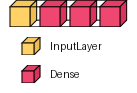

In [56]:
visualkeras.layered_view(model,legend=True)

In [57]:
model.layers[1].weights

[<Variable path=dense_3/kernel, shape=(4, 10), dtype=float32, value=[[-0.30385903 -0.06872213  0.1717478  -0.63919735 -0.51518446  0.62723064
    0.21741074  0.29135346 -0.2038588   0.34221345]
  [-0.34920463  0.05521417 -0.34813812 -0.07633531  0.24304682  0.390154
   -0.5988943   0.55688655  0.33909553 -0.0900861 ]
  [ 0.5687523  -0.02040237 -0.53908116 -0.31770816  0.3323642   0.41592717
   -0.40742087 -0.3501669   0.4270954  -0.31542328]
  [-0.50196546 -0.46789438 -0.30840287 -0.13644654 -0.6538867  -0.2797449
   -0.01311946 -0.2814451   0.37525892  0.18577957]]>,
 <Variable path=dense_3/bias, shape=(10,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]>]

In [58]:
model.layers[3].trainable_variables

[<Variable path=dense_5/kernel, shape=(8, 3), dtype=float32, value=[[-0.7172208   0.23084742 -0.42286223]
  [-0.41150147 -0.5661069   0.4900939 ]
  [ 0.59062093  0.32826525  0.16109657]
  [ 0.12478656  0.20834744 -0.23533827]
  [-0.10130507 -0.5498901  -0.24097648]
  [ 0.6295604  -0.01767421  0.41660064]
  [-0.08619988  0.29931742 -0.24956673]
  [-0.6811984   0.1330179   0.21265006]]>,
 <Variable path=dense_5/bias, shape=(3,), dtype=float32, value=[0. 0. 0.]>]

In [59]:
model.layers[1].bias

<Variable path=dense_3/bias, shape=(10,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]>

In [60]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [61]:
model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["accuracy"])

In [62]:
log_dir = os.path.join("logs","fit",datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1)

In [63]:
model.fit(x_train,y_train,epochs=10,batch_size=8,validation_split=.20,callbacks=[tensorboard_callback])

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.4424 - loss: 1.0304 - val_accuracy: 0.4167 - val_loss: 1.0708
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4819 - loss: 0.9723 - val_accuracy: 0.4583 - val_loss: 1.0259
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4520 - loss: 0.9923 - val_accuracy: 0.4583 - val_loss: 0.9846
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6471 - loss: 0.9412 - val_accuracy: 0.6667 - val_loss: 0.9510
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6820 - loss: 0.9254 - val_accuracy: 0.6667 - val_loss: 0.9211
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7602 - loss: 0.9196 - val_accuracy: 0.7500 - val_loss: 0.8920
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8380 - loss: 0.8477 - val_accuracy: 0.7917 - val_loss: 0.8595
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7550 - loss: 0.8318 - val_accuracy: 0.7917 - v

In [64]:
model.save("model.h5")

In [65]:
model.save("model.keras")

In [66]:
import joblib
joblib.dump(scaler,"scaler.joblib")

['scaler.joblib']

In [67]:
physical_model = tf.keras.models.load_model('model.h5')

In [68]:
physical_scaler = joblib.load("scaler.joblib")

In [69]:
a = [[6.2,2.8,4.8,1.8]]

In [70]:
new_scaled = physical_scaler.transform(a)

In [71]:
physical_model.predict(new_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


array([[0.19440599, 0.3718531 , 0.43374085]], dtype=float32)

In [72]:
iris.target_names[np.argmax(physical_model.predict(new_scaled),axis=1)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


array(['virginica'], dtype='<U10')

In [73]:
def iris_prediction(new_data):
    new_scaled = physical_scaler.transform(new_data)
    class_label = iris.target_names[np.argmax(physical_model.predict(new_scaled),axis=1)]
    return class_label


In [74]:
iris_prediction([[6.2,2.8,4.8,1.8]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array(['virginica'], dtype='<U10')